# Resort Churn Prediction — Neural Network

This notebook trains a small feed-forward neural network (PyTorch) to predict the `Churned` column
in the `resort_train.csv` dataset from the `stepthom/869_course` GitHub repo.

**What the notebook does, end to end:**
1. Downloads the CSV directly from GitHub.
2. Inspects the data and handles missing values.
3. Encodes categorical features and scales numeric features inside a `scikit-learn` pipeline
   (so the same transformations are applied consistently to train and validation data).
4. Splits the data into train / validation sets.
5. Defines a small multi-layer perceptron (MLP) in PyTorch.
6. Trains it with binary cross-entropy and the Adam optimizer.
7. Evaluates accuracy, ROC AUC, and shows the training/validation loss curves.

The code is heavily commented so you can follow each step.

## 1. Install / import dependencies

We use:
- `pandas` / `numpy` for tabular data handling
- `scikit-learn` for the preprocessing pipeline, train/test split, and metrics
- `torch` for the neural network itself
- `matplotlib` for plotting the loss curves

In [38]:
# If any of these are not installed in your environment, uncomment the line below.
# !pip install pandas numpy scikit-learn torch matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn: preprocessing + evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# PyTorch: model, loss, optimizer, data loading
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Make results reproducible — seeding numpy and torch keeps random splits / weight
# initialization / shuffling consistent across runs.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU if one is available; otherwise fall back to CPU. For a dataset this
# small, CPU is perfectly fine.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load the data

We load the CSV straight from GitHub's `raw.githubusercontent.com` URL — that serves the raw file
contents rather than the HTML-rendered GitHub page.

In [39]:
# Raw CSV URL (the github.com/.../blob/... URL would return HTML, not CSV).
#DATA_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_train_cleaned.csv")
#train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/datasets/resort_train.csv")
#train.info()

#df = pd.read_csv(DATA_URL)
df = train

# Quick look at shape, columns, and the first few rows.
print("Shape:", df.shape)
df.head()

Shape: (6954, 22)


,GuestID,PromoCode,Region,AllInclusive,PackageType,VIP,RoomService,Dining,Retail,Spa,...,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned,SharedRoom,RoomFloor,RoomNumber,RoomSide
0,619623,NoPromoCode,Americas,0,Relaxation,0,0,0,0,0,...,5,136,Website,Minor,Facebook,1,0,G,630,S
1,776250,NoPromoCode,Americas,1,Relaxation,0,0,0,0,0,...,5,362,Corporate,Minor,Billboard,1,0,G,201,S
2,932709,NoPromoCode,Americas,0,Wellness,0,0,0,0,0,...,4,154,TravelAgent,Middle,Facebook,0,0,G,1483,S
3,771839,PromoA,Europe,1,Adventure,0,0,0,0,0,...,2,128,Website,Young,Magazine,1,0,D,164,S
4,755501,PromoA,Americas,0,Relaxation,0,0,0,60,1,...,4,35,Mobile,Minor,Google,0,0,G,818,P


In [40]:
# Summary of dtypes and missing-value counts. The dataset has a mix of numeric
# and categorical columns, and some columns contain NaNs that we'll need to
# impute before feeding into the network.
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

GuestID            int64
PromoCode         object
Region            object
AllInclusive       int64
PackageType       object
VIP                int64
RoomService        int64
Dining             int64
Retail             int64
Spa                int64
Entertainment      int64
LoyaltyPoints      int64
SurveyScore        int64
DaysSinceEmail     int64
BookingChannel    object
AgeGroup          object
ReferralSource    object
Churned            int64
SharedRoom         int64
RoomFloor         object
RoomNumber         int64
RoomSide          object
dtype: object

Missing values per column:
GuestID           0
PromoCode         0
RoomNumber        0
RoomFloor         0
SharedRoom        0
Churned           0
ReferralSource    0
AgeGroup          0
BookingChannel    0
DaysSinceEmail    0
SurveyScore       0
LoyaltyPoints     0
Entertainment     0
Spa               0
Retail            0
Dining            0
RoomService       0
VIP               0
PackageType       0
AllInclusive      0
Region  

In [41]:
# Class balance for the target — useful to know before training a binary
# classifier. If the classes were extremely imbalanced we'd consider class
# weights or resampling.
print(df["Churned"].value_counts(normalize=True))

Churned
1    0.503595
0    0.496405
Name: proportion, dtype: float64


## 3. Choose features and target

- **Target (`y`)**: `Churned` — 1 if the guest churned, 0 otherwise.
- **Drop**: `GuestID` (just an identifier, no predictive signal) and `BookingDate` (a raw date
  string; for a first pass we don't engineer date features). If you wanted to use it, you could
  parse it into year/month/day-of-week columns.
- **Numeric features**: continuous columns (spend, age, points, etc.).
- **Categorical features**: string-valued columns (Region, BookingChannel, etc.). These will be
  one-hot encoded.

In [42]:
# Separate target from features.
TARGET = "Churned"
y = df[TARGET].astype(np.float32).values  # float32 because BCE loss expects float targets

# Drop the target and columns that aren't useful as-is.
X = df.drop(columns=[TARGET, "GuestID"])

# Split columns into numeric vs categorical by dtype. pandas reports object/
# string columns as 'object', and numeric ones as int/float.
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric features    :", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features    : ['AllInclusive', 'VIP', 'RoomService', 'Dining', 'Retail', 'Spa', 'Entertainment', 'LoyaltyPoints', 'SurveyScore', 'DaysSinceEmail', 'SharedRoom', 'RoomNumber']
Categorical features: ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomFloor', 'RoomSide']


## 4. Preprocessing pipeline

We build a `ColumnTransformer` that applies different preprocessing to numeric vs categorical
columns:

- **Numeric**: fill missing values with the median, then standardize (zero mean / unit variance).
  Neural networks train much better when inputs are on similar scales.
- **Categorical**: fill missing values with the string `"missing"`, then one-hot encode. We use
  `handle_unknown="ignore"` so that any category seen only in the validation split (and not in
  train) doesn't crash the transform — it becomes an all-zero row instead.

Critically, we fit the pipeline on the **training** data only, then apply it to validation data.
This prevents information leakage (e.g. the validation set's mean influencing the scaler).

In [43]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # robust to outliers
    ("scaler",  StandardScaler()),                  # mean 0, std 1
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    # sparse_output=False so we get a dense numpy array we can hand to torch.
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

## 5. Train / validation split + fit the preprocessor

In [44]:
# 80% train, 20% validation. `stratify=y` ensures both splits keep the same
# proportion of churned/non-churned customers as the original dataset.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Fit on training data only, then transform both splits.
X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)

# After one-hot encoding the feature count is much larger than the raw column count.
n_features = X_train.shape[1]
print("Train matrix shape:", X_train.shape)
print("Val   matrix shape:", X_val.shape)
print("Total input features after encoding:", n_features)

Train matrix shape: (5563, 65)
Val   matrix shape: (1391, 65)
Total input features after encoding: 65


## 6. Wrap the data in PyTorch tensors / DataLoaders

PyTorch operates on `Tensor` objects. A `DataLoader` handles mini-batching and shuffling — we
shuffle the training set each epoch (so the network doesn't memorize batch order) but leave the
validation set in fixed order.

In [45]:
# Convert numpy arrays -> torch tensors. We use float32 for both X and y so the
# whole network can run in fp32 without type-mismatch errors.
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape (N, 1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

# TensorDataset just zips features and labels together so DataLoader can iterate over pairs.
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

## 7. Define the neural network

A small multi-layer perceptron (MLP):

```
input  ->  Linear(64)  -> ReLU -> Dropout
        ->  Linear(32)  -> ReLU -> Dropout
        ->  Linear(1)   ->  (logit, passed to BCEWithLogitsLoss)
```

- **ReLU** is a simple, fast nonlinearity that works well for tabular data.
- **Dropout** randomly zeroes a fraction of activations during training, which acts as a
  regularizer and reduces overfitting.
- We output a single **logit** (raw real number) and use `BCEWithLogitsLoss`, which fuses a
  sigmoid with binary cross-entropy in a numerically stable way.

In [46]:
class ChurnMLP(nn.Module):
    def __init__(self, in_features, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        # nn.Sequential just chains layers; equivalent to writing forward() by hand.
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1),  # single logit output
        )

    def forward(self, x):
        return self.net(x)

model = ChurnMLP(in_features=n_features).to(device)
print(model)

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=65, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 8. Loss and optimizer

- `BCEWithLogitsLoss`: standard loss for binary classification when the model outputs raw logits.
- `Adam`: a solid default optimizer for neural networks — adaptive learning rates, low tuning
  burden. `weight_decay` adds L2 regularization.

In [47]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

## 9. Training loop

Each **epoch** is one pass over the entire training set. Inside each epoch we:
1. Iterate over mini-batches from `train_loader`.
2. Forward pass: compute predictions and the loss.
3. Backward pass: `loss.backward()` computes gradients via autograd.
4. `optimizer.step()` updates the weights, `optimizer.zero_grad()` clears the gradients for the
   next iteration (gradients accumulate by default in PyTorch).

After each epoch we evaluate on the validation set (with `model.eval()` and `torch.no_grad()` so
dropout is disabled and we don't waste compute on gradients).

In [ ]:
def run_epoch(loader, train):
    """Run one pass over `loader`. If train=True, also do backprop + weight update.

    Returns (average loss, all predictions as probabilities, all true labels) — the predictions /
    labels are returned so the caller can compute metrics like accuracy and ROC AUC.
    """
    model.train() if train else model.eval()
    total_loss, n_seen = 0.0, 0
    all_probs, all_targets = [], []

    # torch.set_grad_enabled toggles autograd: on for training, off for eval (saves memory/time).
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)             # forward pass
            loss   = criterion(logits, yb) # BCE on logits

            if train:
                optimizer.zero_grad()       # clear old gradients
                loss.backward()             # compute new gradients
                optimizer.step()            # update weights

            # Accumulate loss weighted by batch size so the average is correct even when
            # the last batch is smaller than the others.
            total_loss += loss.item() * xb.size(0)
            n_seen     += xb.size(0)

            # Convert logits to probabilities for metric calculation later.
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_targets.append(yb.detach().cpu().numpy())

    avg_loss = total_loss / n_seen
    probs    = np.concatenate(all_probs).ravel()
    targets  = np.concatenate(all_targets).ravel()
    return avg_loss, probs, targets


EPOCHS = 30
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _                = run_epoch(train_loader, train=True)
    val_loss,   val_probs, val_true = run_epoch(val_loader,   train=False)

    # Threshold at 0.5 to turn probabilities into hard 0/1 predictions for accuracy.
    val_preds = (val_probs >= 0.5).astype(int)
    val_acc   = accuracy_score(val_true, val_preds)
    val_auc   = roc_auc_score(val_true, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6413 | val_loss=0.5503 | val_acc=0.7707 | val_auc=0.8614
Epoch 02 | train_loss=0.4753 | val_loss=0.4157 | val_acc=0.8066 | val_auc=0.8927
Epoch 03 | train_loss=0.4077 | val_loss=0.4064 | val_acc=0.8109 | val_auc=0.8974
Epoch 04 | train_loss=0.3982 | val_loss=0.3992 | val_acc=0.8239 | val_auc=0.8994
Epoch 05 | train_loss=0.3900 | val_loss=0.3962 | val_acc=0.8217 | val_auc=0.9008
Epoch 06 | train_loss=0.3812 | val_loss=0.3937 | val_acc=0.8196 | val_auc=0.9016
Epoch 07 | train_loss=0.3758 | val_loss=0.3949 | val_acc=0.8239 | val_auc=0.9018
Epoch 08 | train_loss=0.3668 | val_loss=0.3925 | val_acc=0.8181 | val_auc=0.9022
Epoch 09 | train_loss=0.3612 | val_loss=0.3946 | val_acc=0.8167 | val_auc=0.9025
Epoch 10 | train_loss=0.3607 | val_loss=0.3906 | val_acc=0.8239 | val_auc=0.9041
Epoch 11 | train_loss=0.3612 | val_loss=0.3904 | val_acc=0.8260 | val_auc=0.9038
Epoch 12 | train_loss=0.3573 | val_loss=0.3909 | val_acc=0.8239 | val_auc=0.9033
Epoch 13 | train_loss=0.3518

## 10. Final evaluation

A more detailed look at validation performance, including precision/recall/F1 per class.

In [49]:
_, val_probs, val_true = run_epoch(val_loader, train=False)
val_preds = (val_probs >= 0.5).astype(int)

print("Validation accuracy :", accuracy_score(val_true, val_preds))
print("Validation ROC AUC  :", roc_auc_score(val_true, val_probs))
print("\nClassification report:")
print(classification_report(val_true, val_preds, target_names=["not churned", "churned"]))

Validation accuracy : 0.8102084831056794
Validation ROC AUC  : 0.885617854410883

Classification report:
              precision    recall  f1-score   support

 not churned       0.80      0.82      0.81       690
     churned       0.82      0.80      0.81       701

    accuracy                           0.81      1391
   macro avg       0.81      0.81      0.81      1391
weighted avg       0.81      0.81      0.81      1391



## 11. Loss curves

Plotting train vs validation loss helps diagnose under/overfitting:
- Both losses still falling? The model could probably train longer.
- Train loss falling while val loss rises? Overfitting — reduce model size, add dropout/weight decay, or stop earlier.

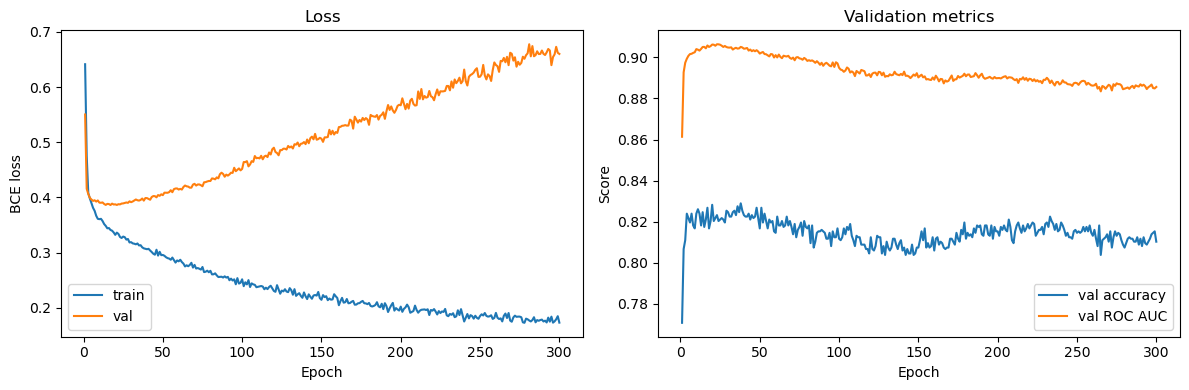

In [50]:
epochs_axis = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, history["train_loss"], label="train")
axes[0].plot(epochs_axis, history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs_axis, history["val_acc"], label="val accuracy")
axes[1].plot(epochs_axis, history["val_auc"], label="val ROC AUC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation metrics"); axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Ideas to improve the model

- **Feature engineering on `BookingDate`** — extract month, day-of-week, days-since-booking, etc.
- **Early stopping** — monitor validation loss and stop when it stops improving for N epochs.
- **Class weights** in `BCEWithLogitsLoss(pos_weight=...)` if you care more about catching the
  minority class.
- **Hyperparameter tuning**: hidden sizes, dropout rate, learning rate, batch size.
- **Compare against a tree-based baseline** like XGBoost or LightGBM — on tabular data these
  often match or beat MLPs with much less tuning.